In [1]:
import os
import sys
import yaml
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import mne

# Magia de Rutas
project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.append(project_root)

# Definir los experimentos que queremos comparar
model_configs = [
    '../../configs/experiments/feat_task_k3_diag_pca90.yaml',
    '../../configs/experiments/feat_task_k4_diag_pca90.yaml',
    '../../configs/experiments/feat_task_k5_diag_pca90.yaml'
]

models_data = {}
features_dir = "../../data/interim/features/task/"

# Cargar el Mega-Vector original (solo se hace una vez porque es igual para todos)
print("Cargando Mega-Vector original...")
feature_files = sorted(glob.glob(os.path.join(features_dir, '*_features.npy')))
X_original = np.vstack([np.load(f) for f in feature_files])
scaler = StandardScaler()
X_zscored = scaler.fit_transform(X_original)

# Cargar los Viterbi Paths de cada modelo
for config_path in model_configs:
    with open(config_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
    
    k = cfg['pipeline']['hmm']['k_states']
    exp_name = cfg['experiment']['name']
    exp_dir = f"../../outputs/processed/experiments/feature_hmm/task/{exp_name}/"
    
    print(f"Cargando modelo K={k}...")
    viterbi = np.load(os.path.join(exp_dir, f'viterbi_paths_k{k}.npy'))
    
    # Calcular perfiles promedio inmediatamente
    state_profiles = []
    for s in range(k):
        idx_state = (viterbi == s)
        state_profiles.append(np.mean(X_zscored[idx_state], axis=0))
        
    models_data[f'K={k}'] = {
        'viterbi': viterbi,
        'profiles': np.array(state_profiles),
        'k': k
    }

print("¡Modelos cargados y listos para la batalla!")

Cargando Mega-Vector original...
Cargando modelo K=3...
Cargando modelo K=4...
Cargando modelo K=5...
¡Modelos cargados y listos para la batalla!


In [2]:
for model_name, data in models_data.items():

    print("=" * 50)
    print(model_name)

    print("Viterbi shape:", data['viterbi'].shape)
    print("Profiles shape:", data['profiles'].shape)

    assert data['viterbi'].shape[0] == X_zscored.shape[0]

print("\nTodo alineado correctamente.")

K=3
Viterbi shape: (143899,)
Profiles shape: (3, 114)
K=4
Viterbi shape: (143899,)
Profiles shape: (4, 114)
K=5
Viterbi shape: (143899,)
Profiles shape: (5, 114)

Todo alineado correctamente.


In [3]:
for model_name, data in models_data.items():

    viterbi = data['viterbi']
    k = data['k']

    print("\n" + "="*60)
    print(model_name)

    total = len(viterbi)

    for s in range(k):

        occ = np.mean(viterbi == s) * 100

        print(f"State {s}: {occ:.2f}%")


K=3
State 0: 6.58%
State 1: 36.75%
State 2: 56.66%

K=4
State 0: 50.74%
State 1: 4.76%
State 2: 18.17%
State 3: 26.33%

K=5
State 0: 23.88%
State 1: 3.68%
State 2: 23.47%
State 3: 14.52%
State 4: 34.46%


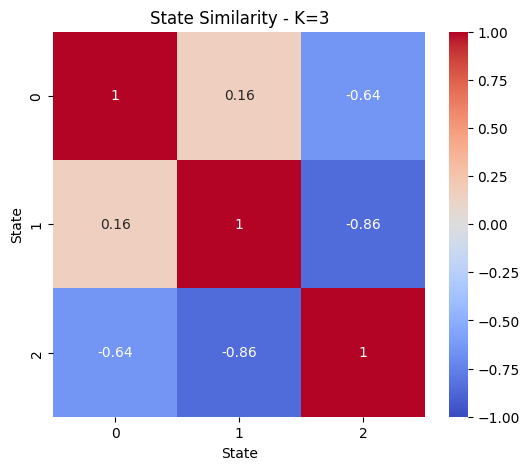

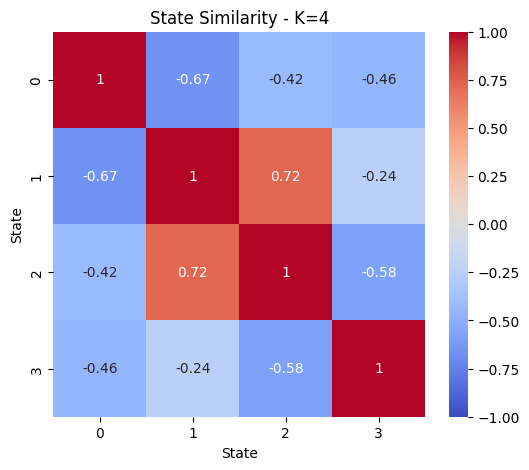

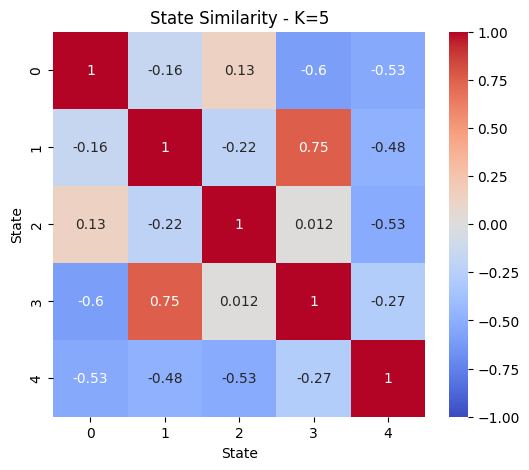

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

for model_name, data in models_data.items():

    profiles = data['profiles']

    sim_matrix = cosine_similarity(profiles)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        sim_matrix,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )

    plt.title(f"State Similarity - {model_name}")
    plt.xlabel("State")
    plt.ylabel("State")

    plt.show()

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# ============================================================
# FUNCIÓN AUXILIAR
# ============================================================

def summarize_similarity(sim_matrix, row_prefix, col_prefix):

    rows = []

    for i in range(sim_matrix.shape[0]):

        best_j = np.argmax(sim_matrix[i])
        best_sim = sim_matrix[i, best_j]

        rows.append({
            f"{row_prefix}_state": i,
            f"best_{col_prefix}_state": best_j,
            "cosine_similarity": round(float(best_sim), 4)
        })

    return pd.DataFrame(rows)


# ============================================================
# 1. SIMILITUD INTERNA (dentro de cada K)
# ============================================================

for model_name, data in models_data.items():

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    profiles = data['profiles']

    sim_matrix = cosine_similarity(profiles)

    # ignorar diagonal
    np.fill_diagonal(sim_matrix, np.nan)

    rows = []

    for s in range(sim_matrix.shape[0]):

        best_match = np.nanargmax(sim_matrix[s])
        best_sim = sim_matrix[s, best_match]

        rows.append({
            "state": s,
            "most_similar_state": int(best_match),
            "similarity": round(float(best_sim), 4)
        })

    df_internal = pd.DataFrame(rows)

    print(df_internal)

    mean_sim = np.nanmean(sim_matrix)

    print(f"\nMean inter-state similarity: {mean_sim:.4f}")


K=3
   state  most_similar_state  similarity
0      0                   1      0.1583
1      1                   0      0.1583
2      2                   0     -0.6426

Mean inter-state similarity: -0.4475

K=4
   state  most_similar_state  similarity
0      0                   2     -0.4233
1      1                   2      0.7225
2      2                   1      0.7225
3      3                   1     -0.2396

Mean inter-state similarity: -0.2751

K=5
   state  most_similar_state  similarity
0      0                   2      0.1338
1      1                   3      0.7521
2      2                   0      0.1338
3      3                   1      0.7521
4      4                   3     -0.2746

Mean inter-state similarity: -0.1892


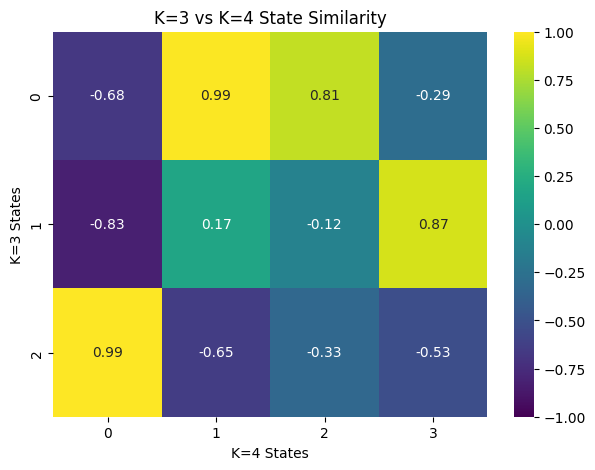

In [6]:
profiles_k3 = models_data['K=3']['profiles']
profiles_k4 = models_data['K=4']['profiles']

cross_sim = cosine_similarity(
    profiles_k3,
    profiles_k4
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cross_sim,
    annot=True,
    cmap='viridis',
    vmin=-1,
    vmax=1
)

plt.title("K=3 vs K=4 State Similarity")
plt.xlabel("K=4 States")
plt.ylabel("K=3 States")

plt.show()

In [7]:
# ============================================================
# 2. K=3 vs K=4
# ============================================================

profiles_k3 = models_data['K=3']['profiles']
profiles_k4 = models_data['K=4']['profiles']

cross_sim_34 = cosine_similarity(
    profiles_k3,
    profiles_k4
)

df_34 = summarize_similarity(
    cross_sim_34,
    row_prefix="k3",
    col_prefix="k4"
)

print("\n" + "="*60)
print("K=3 vs K=4")
print("="*60)

print(df_34)


# ============================================================
# 3. K=4 vs K=5
# ============================================================

profiles_k4 = models_data['K=4']['profiles']
profiles_k5 = models_data['K=5']['profiles']

cross_sim_45 = cosine_similarity(
    profiles_k4,
    profiles_k5
)

df_45 = summarize_similarity(
    cross_sim_45,
    row_prefix="k4",
    col_prefix="k5"
)

print("\n" + "="*60)
print("K=4 vs K=5")
print("="*60)

print(df_45)


# ============================================================
# 4. K=3 vs K=5
# ============================================================

profiles_k3 = models_data['K=3']['profiles']
profiles_k5 = models_data['K=5']['profiles']

cross_sim_35 = cosine_similarity(
    profiles_k3,
    profiles_k5
)

df_35 = summarize_similarity(
    cross_sim_35,
    row_prefix="k3",
    col_prefix="k5"
)

print("\n" + "="*60)
print("K=3 vs K=5")
print("="*60)

print(df_35)


K=3 vs K=4
   k3_state  best_k4_state  cosine_similarity
0         0              1             0.9877
1         1              3             0.8737
2         2              0             0.9931

K=4 vs K=5
   k4_state  best_k5_state  cosine_similarity
0         0              4             0.9221
1         1              1             0.9971
2         2              3             0.9719
3         3              0             0.9974

K=3 vs K=5
   k3_state  best_k5_state  cosine_similarity
0         0              1             0.9758
1         1              0             0.8984
2         2              4             0.8909


In [8]:
from scipy.stats import entropy

for model_name, data in models_data.items():

    viterbi = data['viterbi']
    k = data['k']

    trans = np.zeros((k,k))

    for i in range(len(viterbi)-1):
        trans[viterbi[i], viterbi[i+1]] += 1

    trans = trans / trans.sum(axis=1, keepdims=True)

    entropies = []

    for row in trans:
        entropies.append(entropy(row))

    print(f"\n{model_name}")
    print("Mean transition entropy:", np.mean(entropies))


K=3
Mean transition entropy: 0.6884249311618795

K=4
Mean transition entropy: 0.7868441665860059

K=5
Mean transition entropy: 0.8631812719312724


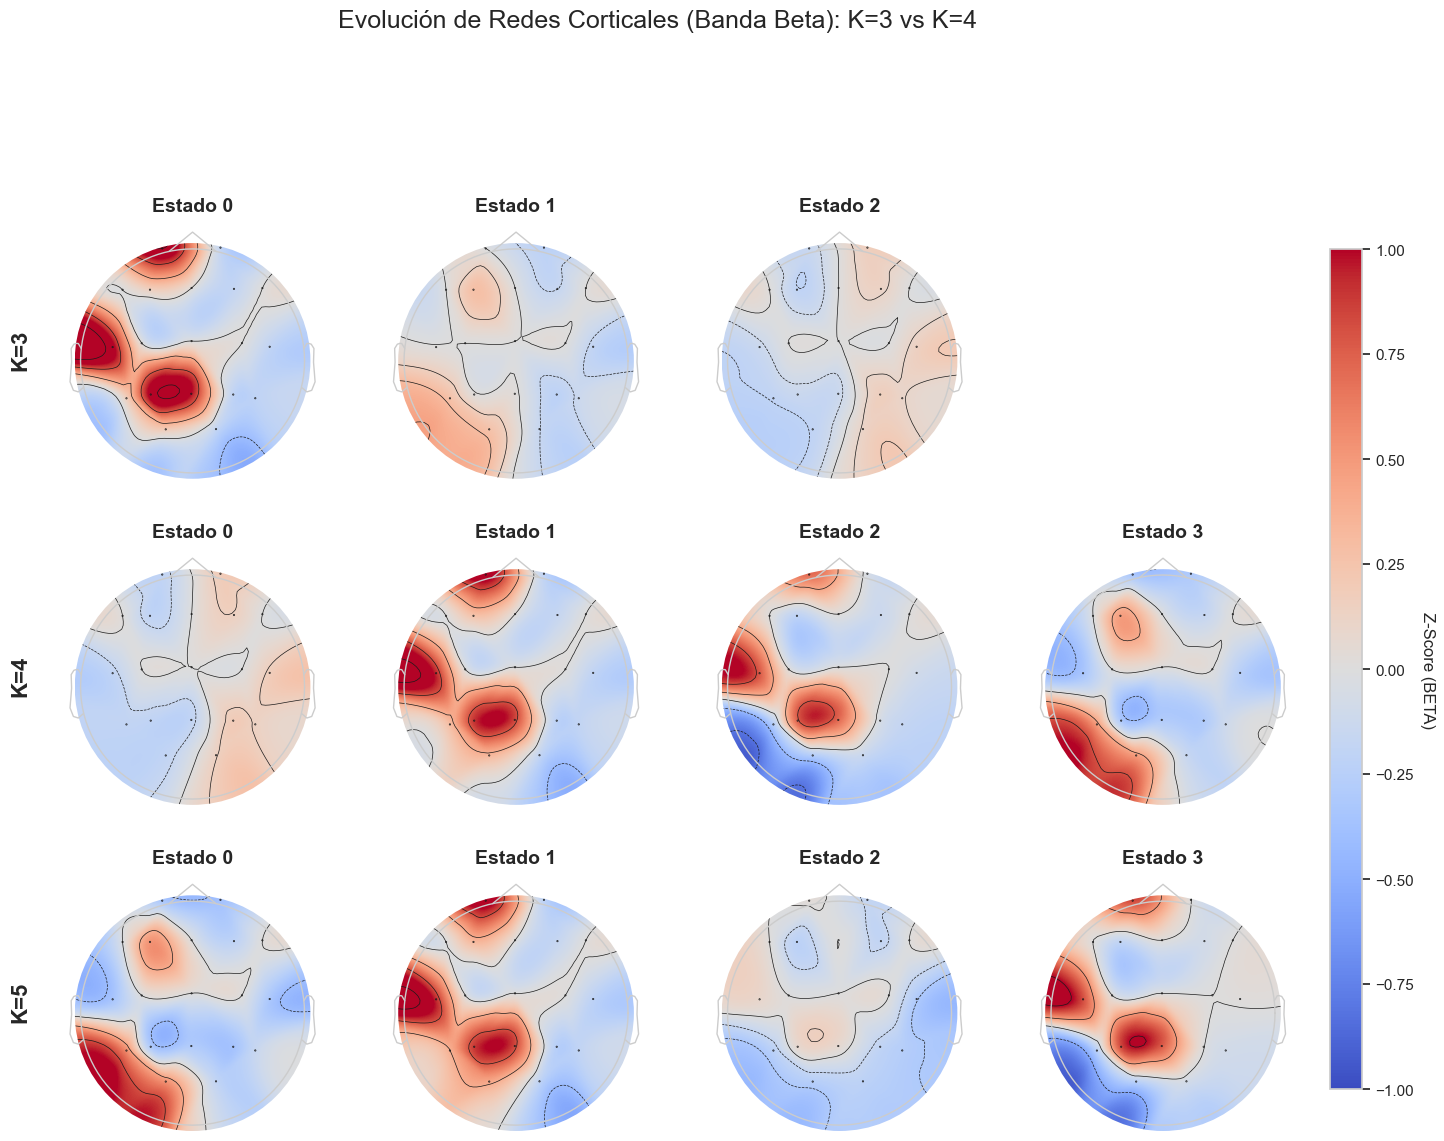

In [12]:
# ============================================================
# EVOLUCIÓN TOPOGRÁFICA (Comparativa de Banda BETA)
# ============================================================

ch_names = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2','F7','F8','T3','T4','T5','T6','Fz','Cz','Pz']
info = mne.create_info(ch_names=ch_names, sfreq=250., ch_types='eeg')
info.set_montage('standard_1020')

# Vamos a enfocarnos solo en Beta para ver la red motora/inhibitoria (Métrica índice 2 en tu Mega-Vector)
BETA_IDX = 2 

fig, axes = plt.subplots(len(models_data), 4, figsize=(16, 4 * len(models_data))) # 4 columnas máximo

for row_idx, (model_name, data) in enumerate(models_data.items()):
    k = data['k']
    profiles = data['profiles']
    
    # Convertir a 3D (Extrayendo solo el bloque de Beta)
    start_col = BETA_IDX * len(ch_names)
    end_col = (BETA_IDX + 1) * len(ch_names)
    beta_profiles = profiles[:, start_col:end_col]
    
    for s in range(4): # Forzamos 4 columnas para que el grid quede alineado
        ax = axes[row_idx, s]
        
        if s < k: # Si el estado existe en este modelo
            im, _ = mne.viz.plot_topomap(
                beta_profiles[s], 
                pos=info, axes=ax, cmap='coolwarm', vlim=(-1, 1), 
                show=False, contours=4, sphere=(0.0, 0.0, 0.0, 0.1)
            )
            ax.set_title(f"Estado {s}", fontsize=14, fontweight='bold')
        else: # Dejar la celda vacía para K=3 en la columna 4
            ax.axis('off')
            
        if s == 0:
            ax.set_ylabel(model_name, fontsize=16, fontweight='bold', labelpad=20)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label('Z-Score (BETA)', rotation=270, labelpad=15)

plt.suptitle("Evolución de Redes Corticales (Banda Beta): K=3 vs K=4", fontsize=18, y=1.05)
plt.show()

In [13]:
# ============================================================
# COMPARATIVA DE SENSIBILIDAD CLÍNICA (Tasa de Transición)
# ============================================================

# 1. Configurar el estilo visual
sns.set_theme(style="whitegrid", palette="muted")

# 2. GRAFICAR: Comparativa de Modelos (K=3 vs K=4)
# Usamos catplot para mantener la consistencia estética
g_comp = sns.catplot(
    data=df_comp, 
    x='Model', 
    y='Transition_Rate_Hz', 
    hue='Group', 
    kind='box', 
    height=6, 
    aspect=1.2,
    palette='Set2',      # Una paleta limpia
    boxprops={'alpha': 0.6},
    legend_out=True
)

# 3. Añadir la dispersión de puntos (Stripplot)
# Esto es lo que le da el toque "pro" para ver cada ensayo/sujeto
g_comp.map_dataframe(
    sns.stripplot, 
    x='Model', 
    y='Transition_Rate_Hz', 
    hue='Group', 
    dodge=True, 
    alpha=0.4,           # Un poco más transparente para no saturar
    palette='dark:.3',
    marker='o',
    size=4
)

# 4. Ajustes finos de títulos y ejes
g_comp.fig.subplots_adjust(top=0.85)
g_comp.fig.suptitle(
    "Evaluación de Modelos: Tasa de Transición Global\n(Flexibilidad Cortical)", 
    fontsize=16, 
    fontweight='bold'
)

g_comp.set_axis_labels("Configuración del Modelo", "Frecuencia de Cambio (Hz)")
g_comp.set_titles("{col_name}") # Por si decides añadir col='Condition' en el futuro

plt.show()

NameError: name 'df_comp' is not defined

,Model,Log_Likelihood,Free_Parameters,BIC
0,K=3,-9634946.63,302,19273480.08
1,K=4,-9539781.85,407,19084397.59
2,K=5,-9487387.36,514,18980879.43


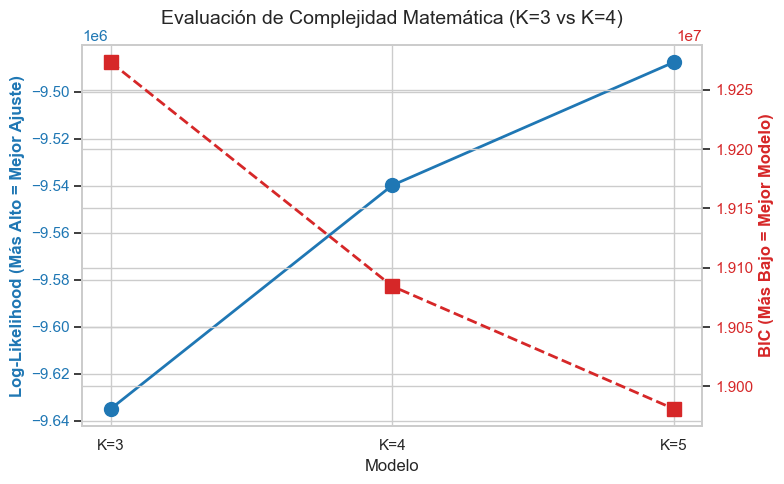

In [14]:
# ============================================================
# EVALUACIÓN MATEMÁTICA: Log-Likelihood y BIC (Equivalente Free Energy)
# ============================================================
import joblib

# Total de ventanas (observaciones)
N_obs = len(X_zscored) 
math_stats = []

for config_path in model_configs:
    with open(config_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
        
    k = cfg['pipeline']['hmm']['k_states']
    exp_name = cfg['experiment']['name']
    exp_dir = f"../../outputs/processed/experiments/feature_hmm/task/{exp_name}/"
    
    # Cargar el modelo entrenado (.pkl)
    model_path = os.path.join(exp_dir, f'hmm_model_k{k}.pkl')
    if os.path.exists(model_path):
        model = joblib.load(model_path)
        
        # 1. Extraer el Log-Likelihood Final (El pico de convergencia)
        final_log_likelihood = model.monitor_.history[-1]
        
        # 2. Calcular el número de parámetros libres (Para covarianza 'diag')
        # Parámetros = Transiciones + Medias + Varianzas + Probabilidades Iniciales
        n_features = model.n_features
        n_params = (k * (k - 1)) + (k * n_features) + (k * n_features) + (k - 1)
        
        # 3. Calcular el BIC (Bayesian Information Criterion)
        # Fórmula: -2 * ln(L) + p * ln(N)
        bic = -2 * final_log_likelihood + n_params * np.log(N_obs)
        
        math_stats.append({
            'Model': f'K={k}',
            'Log_Likelihood': final_log_likelihood,
            'Free_Parameters': n_params,
            'BIC': bic
        })
    else:
        print(f"No se encontró el modelo .pkl para K={k}")

df_math = pd.DataFrame(math_stats)

# Visualización Rápida
display(df_math.round(2))

# Gráfica de penalización
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Modelo')
ax1.set_ylabel('Log-Likelihood (Más Alto = Mejor Ajuste)', color=color, fontweight='bold')
ax1.plot(df_math['Model'], df_math['Log_Likelihood'], marker='o', markersize=10, color=color, linewidth=2, label='Ajuste')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('BIC (Más Bajo = Mejor Modelo)', color=color, fontweight='bold')
ax2.plot(df_math['Model'], df_math['BIC'], marker='s', markersize=10, color=color, linewidth=2, linestyle='--', label='Penalización (BIC)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Evaluación de Complejidad Matemática (K=3 vs K=4)", fontsize=14, pad=15)
fig.tight_layout()  
plt.show()

In [18]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def hungarian_state_matching(base_profiles, target_profiles):

    # ======================================================
    # 1. MATRIZ DE SIMILITUD
    # ======================================================

    sim_matrix = cosine_similarity(base_profiles, target_profiles)

    # ======================================================
    # 2. MATRIZ DE COSTO
    # ======================================================

    cost_matrix = 1 - sim_matrix

    # ======================================================
    # 3. HUNGARIAN MATCHING
    # ======================================================

    base_idx, target_idx = linear_sum_assignment(cost_matrix)

    # ======================================================
    # 4. TABLA DE MATCHING
    # ======================================================

    matches = []

    matched_targets = set()

    for b, t in zip(base_idx, target_idx):

        matches.append({
            'base_state': b,
            'target_state': t,
            'similarity': sim_matrix[b, t]
        })

        matched_targets.add(t)

    # ======================================================
    # 5. ESTADOS NO ASIGNADOS
    # ======================================================

    unmatched = []

    for t in range(target_profiles.shape[0]):

        if t not in matched_targets:

            best_base = np.argmax(sim_matrix[:, t])

            unmatched.append({
                'target_state': t,
                'closest_base_state': best_base,
                'similarity': sim_matrix[best_base, t]
            })

    matches_df = pd.DataFrame(matches)
    unmatched_df = pd.DataFrame(unmatched)

    return {
        'similarity_matrix': sim_matrix,
        'matches': matches_df,
        'unmatched': unmatched_df
    }

In [19]:
results_k4 = hungarian_state_matching(
    models_data['K=3']['profiles'],
    models_data['K=4']['profiles']
)

print(results_k4['matches'])

print(results_k4['unmatched'])

   base_state  target_state  similarity
0           0             1    0.987690
1           1             3    0.873698
2           2             0    0.993101
   target_state  closest_base_state  similarity
0             2                   0    0.813088


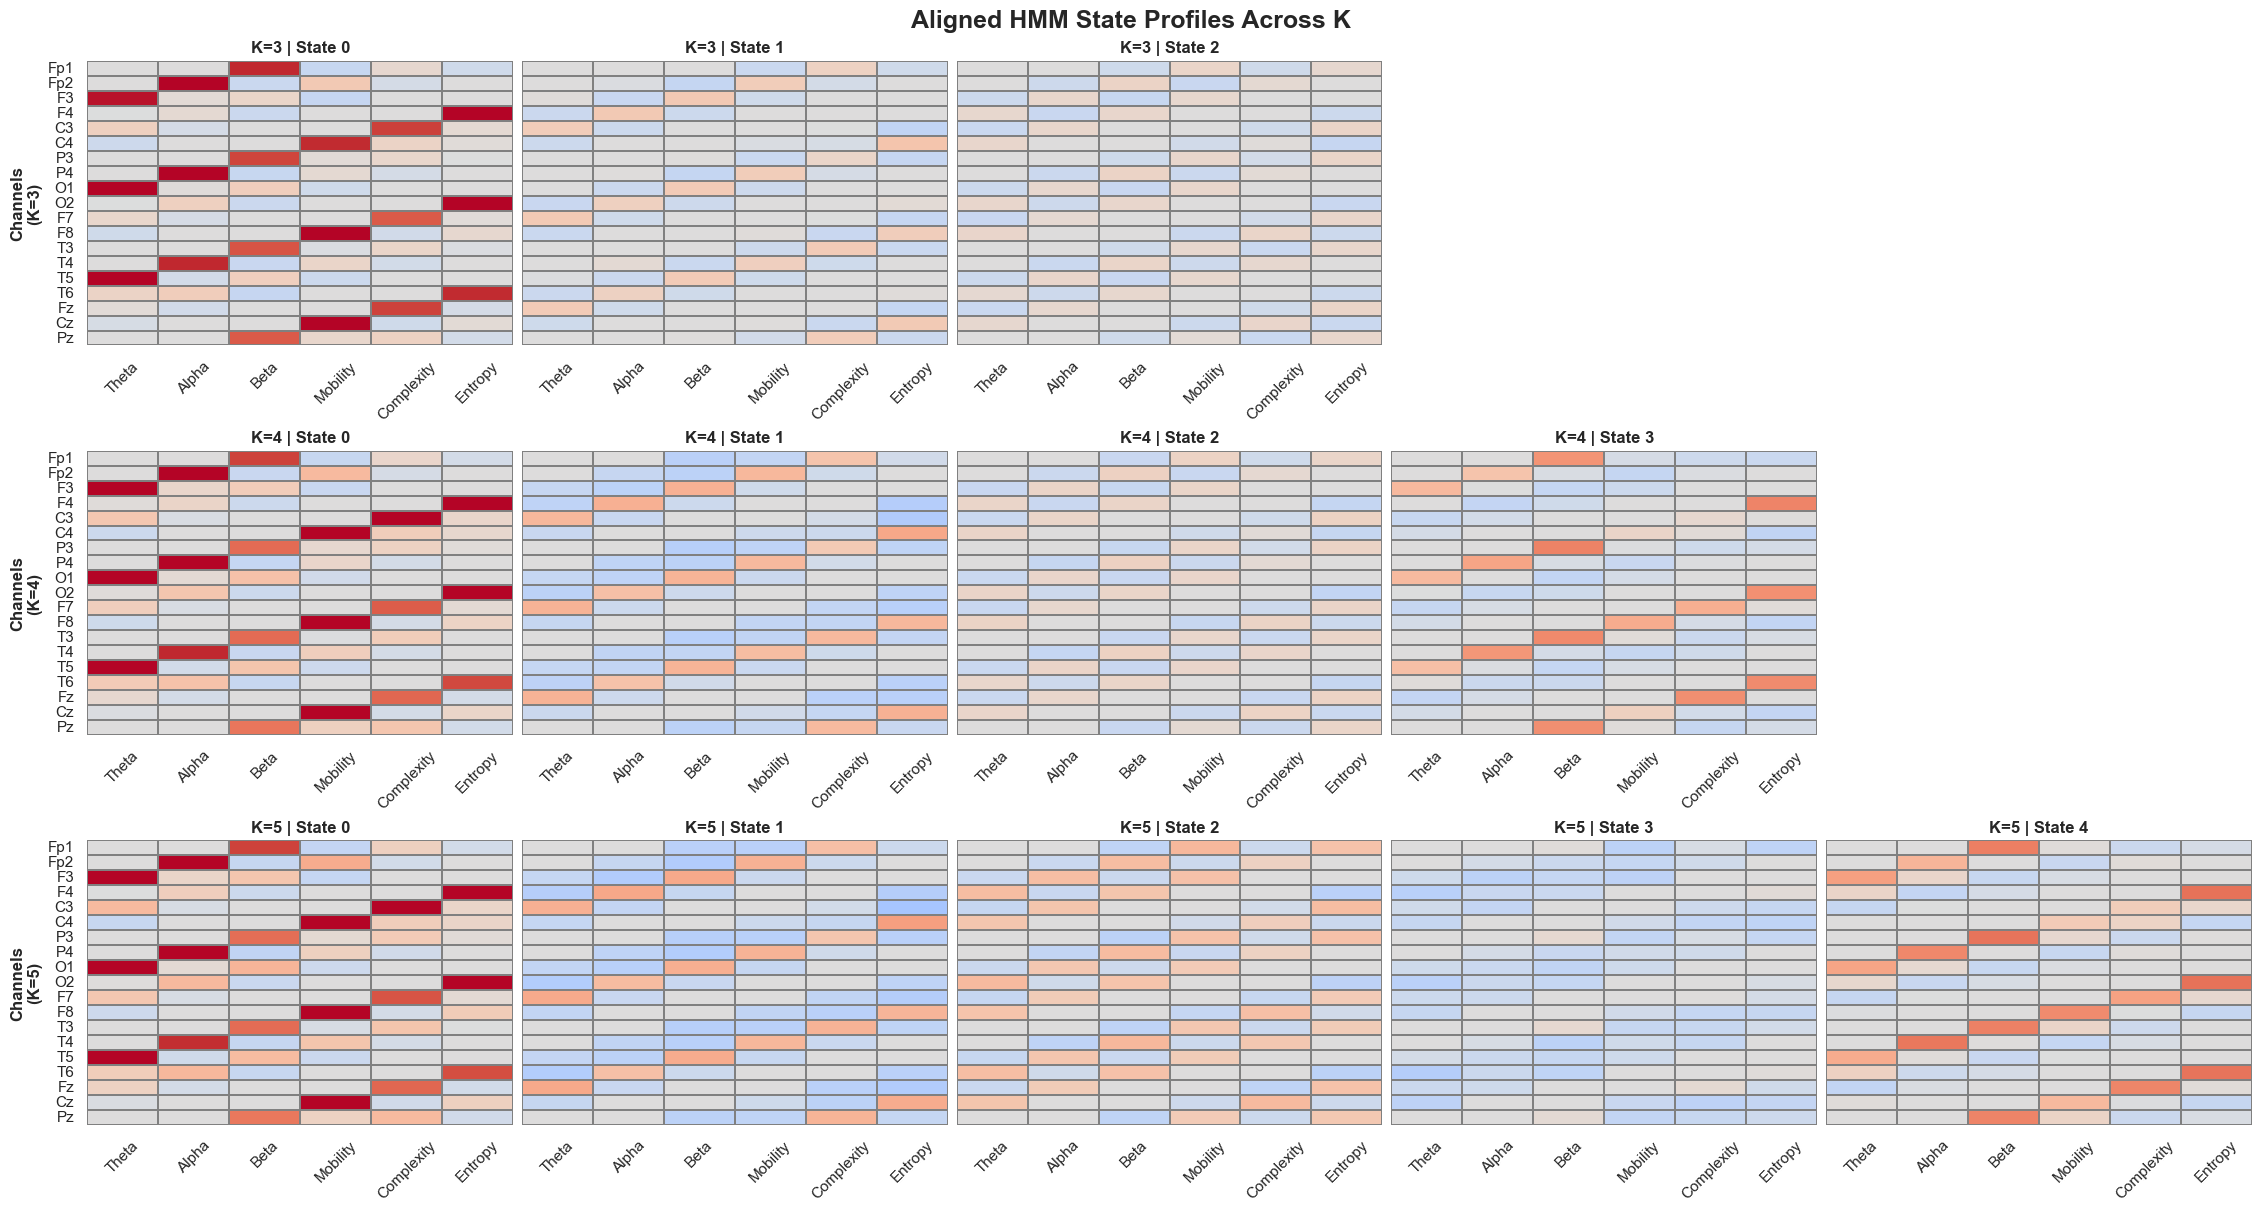

In [21]:
# ============================================================
# COMPARATIVA DE PERFILES ESPECTRALES ALINEADOS (MEJORADA)
# ============================================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
ch_names = [
    'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
    'F7','F8','T3','T4','T5','T6','Fz','Cz','Pz'
]

metrics = [
    'Theta', 'Alpha', 'Beta',
    'Mobility', 'Complexity', 'Entropy'
]

k_to_compare = [3, 4, 5]

# ------------------------------------------------------------
# CALCULAR ESCALA GLOBAL PARA COMPARACIÓN JUSTA
# ------------------------------------------------------------
all_values = []

for k in k_to_compare:
    profiles = aligned_models[f'K={k}']['profiles']
    all_values.append(profiles)

all_values = np.concatenate(all_values, axis=0)

global_absmax = np.percentile(np.abs(all_values), 98)

# ------------------------------------------------------------
# FIGURA
# ------------------------------------------------------------
max_states = max(k_to_compare)

fig, axes = plt.subplots(
    nrows=len(k_to_compare),
    ncols=max_states,
    figsize=(4.5 * max_states, 4 * len(k_to_compare)),
    constrained_layout=True
)

# Evitar bugs cuando solo hay una fila
if len(k_to_compare) == 1:
    axes = np.expand_dims(axes, axis=0)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
for row_idx, k in enumerate(k_to_compare):

    profiles = aligned_models[f'K={k}']['profiles']

    # Convertir vector plano -> matriz (channels x metrics)
    profiles_3d = profiles.reshape(
        k,
        len(metrics),
        len(ch_names)
    ).transpose(0, 2, 1)

    for state_idx in range(max_states):

        ax = axes[row_idx, state_idx]

        # ----------------------------------------------------
        # Si el estado NO existe -> apagar eje
        # ----------------------------------------------------
        if state_idx >= k:
            ax.axis('off')
            continue

        # ----------------------------------------------------
        # Heatmap
        # ----------------------------------------------------
        sns.heatmap(
            profiles_3d[state_idx],
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=-global_absmax,
            vmax=global_absmax,
            xticklabels=metrics,
            yticklabels=ch_names if state_idx == 0 else False,
            cbar=(row_idx == 0 and state_idx == max_states - 1),
            linewidths=0.3,
            linecolor='gray'
        )

        # ----------------------------------------------------
        # Títulos
        # ----------------------------------------------------
        ax.set_title(
            f"K={k} | State {state_idx}",
            fontsize=12,
            fontweight='bold'
        )

        ax.tick_params(axis='x', rotation=45)

        # ----------------------------------------------------
        # Etiqueta lateral
        # ----------------------------------------------------
        if state_idx == 0:
            ax.set_ylabel(
                f"Channels\n(K={k})",
                fontsize=12,
                fontweight='bold'
            )

# ------------------------------------------------------------
# SUPER TÍTULO
# ------------------------------------------------------------
fig.suptitle(
    "Aligned HMM State Profiles Across K",
    fontsize=18,
    fontweight='bold'
)

plt.show()

  Model                Subject  Epoch     State     FO (%)  Dwell Time (ms)  \
0   K=3  AAELSCGO_sin_contexto      0  Estado 0   0.000000              NaN   
1   K=3  AAELSCGO_sin_contexto      0  Estado 1  29.508197            200.0   
2   K=3  AAELSCGO_sin_contexto      0  Estado 2  70.491803            430.0   
3   K=3  AAELSCGO_sin_contexto      1  Estado 0   0.000000              NaN   
4   K=3  AAELSCGO_sin_contexto      1  Estado 1  31.147541            237.5   

   Switching Rate (Hz)  
0             2.950820  
1             2.950820  
2             2.950820  
3             2.622951  
4             2.622951  


FO (%)        Dwell Time (ms)         Switching Rate (Hz)      
                 mean    std            mean     std                mean   std
Model State                                                                   
K=3   Estado 0   6.58  13.38          229.58  177.73                2.66  0.76
      Estado 1  36.75  15.89          269.52  112.31                2.66  0.76
      Estado 2  56.66  23.07          495.08  283.91                2.66  0.76
K=4   Estado 0   4.76  11.49          216.18  174.39                2.57  0.68
      Estado 1  26.33  16.12          260.34  125.13                2.57  0.68
      Estado 2  50.74  23.82          455.80  245.48                2.57  0.68
      Estado 3  18.17  21.06          436.16  316.56                2.57  0.68
K=5   Estado 0   3.68   9.72          198.47  131.20                2.53  0.67
      Estado 1  23.88  15.80          254.68  127.57                2.53  0.67
      Estado 2  34.46  24.94          476.48  280.87                2.53  0.67
      Estado 3  23.47  20.92          432.18  273.86                2.53  0.67
      Estado 4  14.52  20.39          345.95  216.76                2.53  0.67

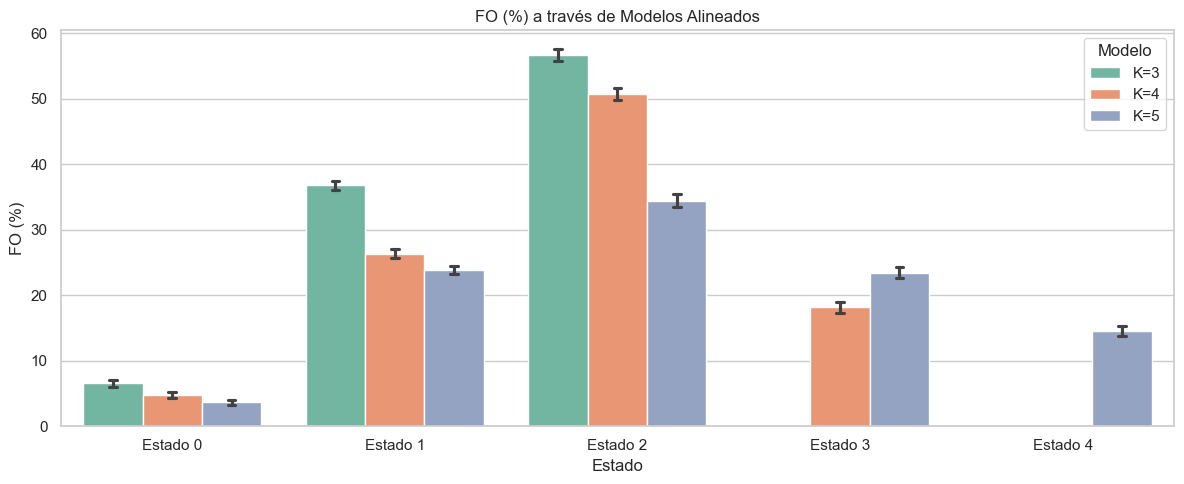

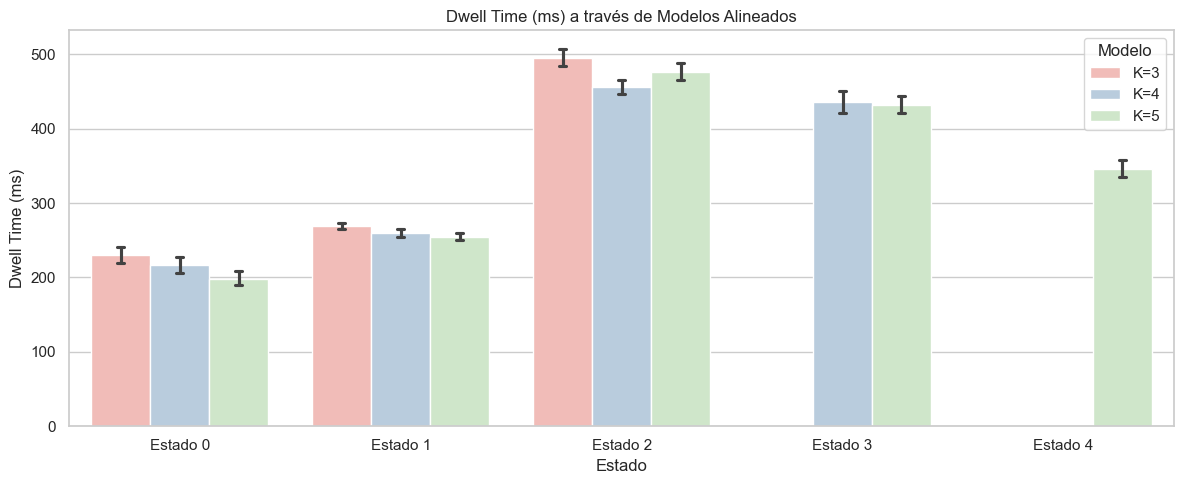

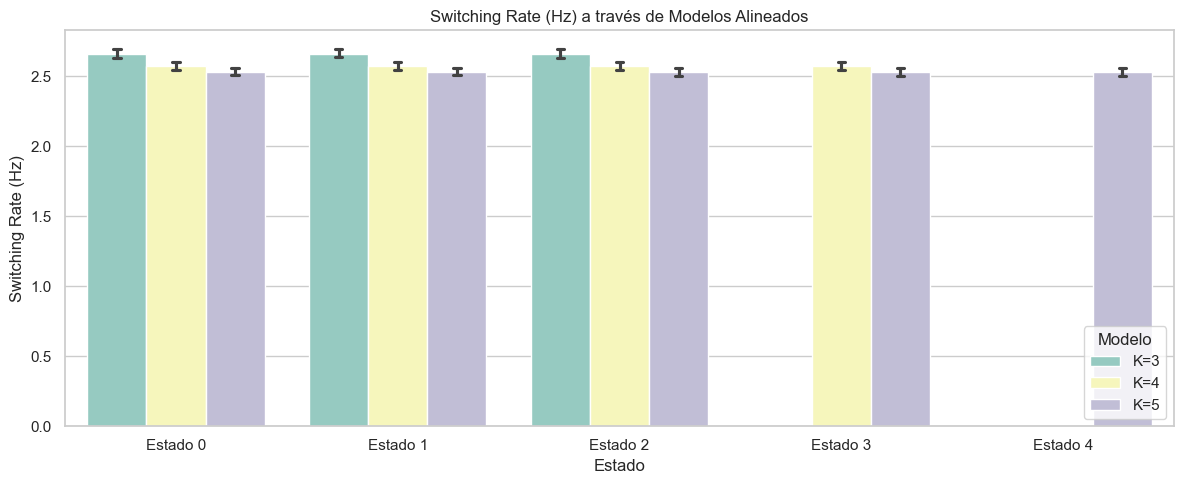

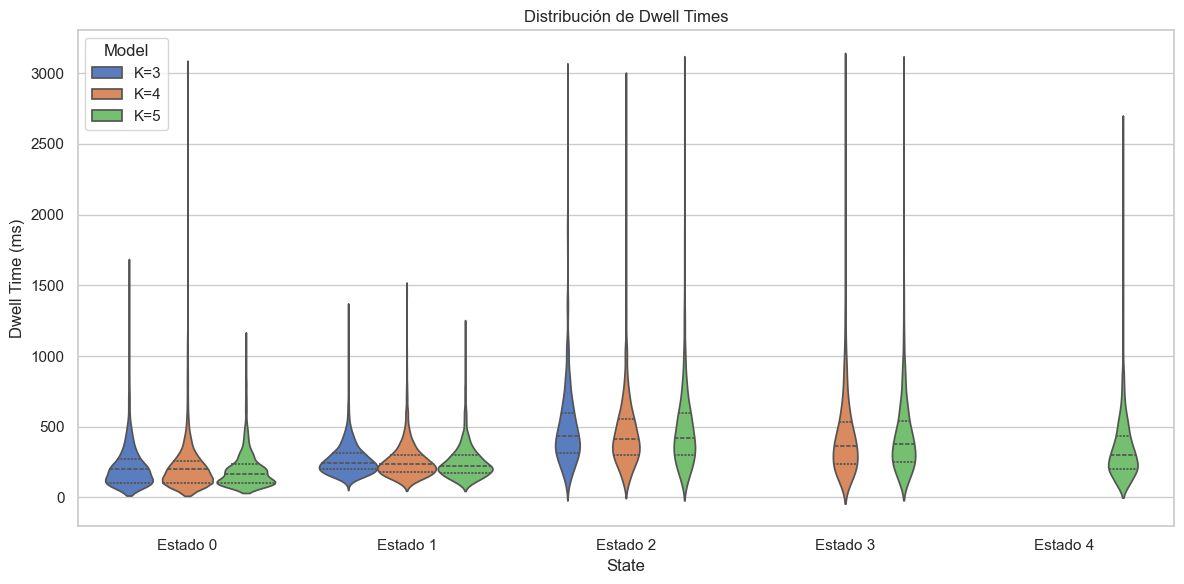

In [22]:
# ============================================================
# COMPARATIVA DE MÉTRICAS CLÍNICAS (FO, Dwell, Switching)
# ============================================================

import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

features_dir = "../../data/interim/features/task/"
subject_files = sorted(glob.glob(os.path.join(features_dir, '*_lengths.npy')))

WINDOW_STEP_MS = 100


# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def compute_dwell_times(path, state, step_ms=100):
    """
    Retorna TODOS los dwell times del estado en ms.
    """
    mask = (path == state)

    if not np.any(mask):
        return np.array([])

    diffs = np.diff(np.concatenate(([0], mask.astype(int), [0])))

    starts = np.where(diffs == 1)[0]
    ends = np.where(diffs == -1)[0]

    durations = (ends - starts) * step_ms

    return durations


def compute_switching_rate(path, step_ms=100):
    """
    Switching rate en Hz.
    """
    n_transitions = np.sum(np.diff(path) != 0)

    total_time_sec = (len(path) * step_ms) / 1000

    if total_time_sec == 0:
        return np.nan

    return n_transitions / total_time_sec


# ------------------------------------------------------------
# Extraer métricas
# ------------------------------------------------------------

clinical_stats = []

for model_name, data in aligned_models.items():

    k = data['k']
    viterbi_aligned = data['viterbi']

    start_idx = 0

    for subj_file in subject_files:

        subj_id = os.path.basename(subj_file).replace('_lengths.npy', '')

        subj_lengths = np.load(subj_file)

        for epoch_idx, ep_len in enumerate(subj_lengths):

            ep_path = viterbi_aligned[start_idx:start_idx + ep_len]

            switch_rate = compute_switching_rate(
                ep_path,
                step_ms=WINDOW_STEP_MS
            )

            for s in range(max_states):

                if s >= k:
                    continue

                # Fractional Occupancy
                fo = np.mean(ep_path == s) * 100

                # Dwell
                dwell_values = compute_dwell_times(
                    ep_path,
                    state=s,
                    step_ms=WINDOW_STEP_MS
                )

                mean_dwell = (
                    np.mean(dwell_values)
                    if len(dwell_values) > 0
                    else np.nan
                )

                clinical_stats.append({
                    'Model': model_name,
                    'Subject': subj_id,
                    'Epoch': epoch_idx,
                    'State': f'Estado {s}',
                    'FO (%)': fo,
                    'Dwell Time (ms)': mean_dwell,
                    'Switching Rate (Hz)': switch_rate
                })

            start_idx += ep_len


df_clinical = pd.DataFrame(clinical_stats)

print(df_clinical.head())


# ============================================================
# RESUMEN NUMÉRICO
# ============================================================

summary_df = (
    df_clinical
    .groupby(['Model', 'State'])
    .agg({
        'FO (%)': ['mean', 'std'],
        'Dwell Time (ms)': ['mean', 'std'],
        'Switching Rate (Hz)': ['mean', 'std']
    })
    .round(2)
)

display(summary_df)


# ============================================================
# PLOTS
# ============================================================

sns.set_style("whitegrid")

metrics_to_plot = [
    'FO (%)',
    'Dwell Time (ms)',
    'Switching Rate (Hz)'
]

palettes = {
    'FO (%)': 'Set2',
    'Dwell Time (ms)': 'Pastel1',
    'Switching Rate (Hz)': 'Set3'
}

for metric in metrics_to_plot:

    plt.figure(figsize=(12, 5))

    sns.barplot(
        data=df_clinical,
        x='State',
        y=metric,
        hue='Model',
        palette=palettes[metric],
        errorbar='ci',
        capsize=0.1
    )

    plt.title(f"{metric} a través de Modelos Alineados")
    plt.xlabel("Estado")
    plt.ylabel(metric)

    plt.legend(title='Modelo')

    plt.tight_layout()
    plt.show()


# ============================================================
# BONUS: DISTRIBUCIÓN COMPLETA DE DWELL TIMES
# ============================================================

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df_clinical,
    x='State',
    y='Dwell Time (ms)',
    hue='Model',
    split=False,
    inner='quartile'
)

plt.title("Distribución de Dwell Times")
plt.tight_layout()
plt.show()